# 06. Anomaly Detection

## Objective: 

Identify customers whose **behavioral patterns are unusual** relative to the overall customer population. (e.g., massive wholesale buyers, extreme cancellation rates) that deviate from our core ***K=3*** segments before deploying the inference pipeline.

> Because the dataset has no ground-truth anomaly labels, this notebook does **not** report accuracy, precision, recall, or F1. The focus is on behavioral plausibility, robustness, and interpretability.

### Import Required Libraries

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

### Data Loading

Load the robust-scaled feature matrix (X_robust) and the final customer dataset (customer_df), setting Customer ID as the primary index for consistent row alignment across downstream analysis steps.

In [2]:
X_robust = pd.read_csv('../data/processed/X_robust.csv', index_col='Customer ID')
customer_df = pd.read_csv('../data/processed/final_customer_segmentation.csv', index_col='Customer ID')

### Set the Initial Anomaly Rate

There are no labeled anomalies in this dataset, so the contamination level is a **modeling assumption**, not a measured property of the data.

We start with **1%** as a conservative threshold and later perform a sensitivity analysis.

In [3]:
contamination_values = [0.01, 0.02, 0.03, 0.05]

contamination_records = []
for contamination in contamination_values:
    model = IsolationForest(
        n_estimators=300,
        contamination=contamination,
        random_state=42,
        n_jobs=-1,
    )
    labels = model.fit_predict(X_robust)
    contamination_records.append({
        "Configured_Contamination_%": contamination * 100,
        "Detected_Anomalies": int((labels == -1).sum()),
        "Observed_Anomaly_Rate_%": (labels == -1).mean() * 100,
    })

contamination_summary = pd.DataFrame(contamination_records)
contamination_summary.round(2)

,Configured_Contamination_%,Detected_Anomalies,Observed_Anomaly_Rate_%
0,1.0,59,1.00
1,2.0,118,2.01
2,3.0,177,3.01
3,5.0,294,5.00


### Primary Model — Isolation Forest

Isolation Forest is the primary detector because it is well suited to unlabeled, multivariate tabular data and does not assume a Gaussian distribution.

The model identifies observations that are easier to isolate from the majority of customers.

`sklearn` returns `-1` for anomalies and `1` for normal observations. The score should be interpreted primarily as a **relative ranking of unusualness**, not as an estimated probability that a customer is anomalous.

In [4]:
isolation_forest = IsolationForest(
    n_estimators=300,
    contamination=0.01,
    random_state=42,
    n_jobs=-1,
)

if_labels = isolation_forest.fit_predict(X_robust)
if_scores = -isolation_forest.decision_function(X_robust)

isolation_results = pd.DataFrame({
    "IF_Label": np.where(if_labels == -1, "Anomaly", "Normal"),
    "IF_Anomaly_Score": if_scores,
}, index=customer_df.index)

print(f"Anomalies: {(if_labels == -1).sum():,} ({(if_labels == -1).mean() * 100:.2f}%)")

Anomalies: 59 (1.00%)


### Isolation Forest Score Distribution

The anomaly score is primarily a **ranking signal**, not a probability. Customers with higher scores are more unusual according to the fitted Isolation Forest.

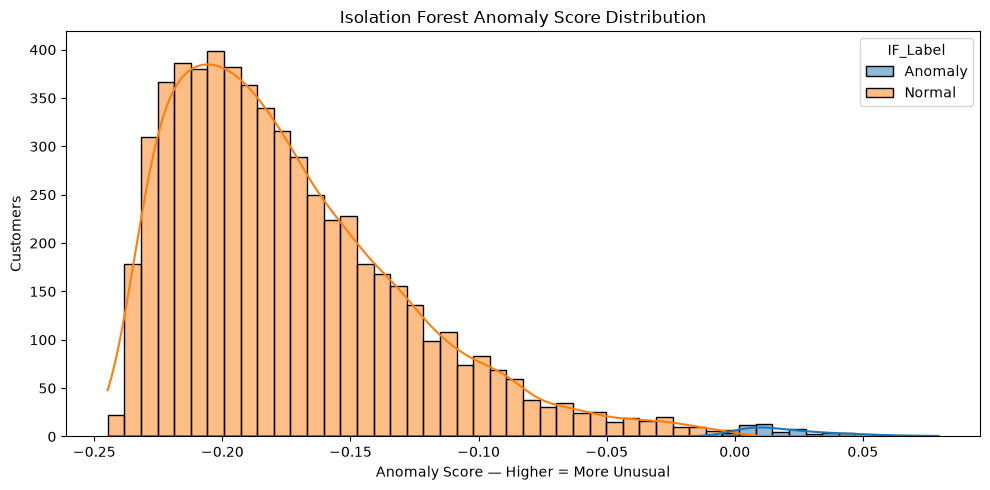

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=isolation_results,
    x="IF_Anomaly_Score",
    hue="IF_Label",
    bins=50,
    kde=True,
)

plt.title("Isolation Forest Anomaly Score Distribution")
plt.xlabel("Anomaly Score — Higher = More Unusual")
plt.ylabel("Customers")
plt.tight_layout()

### Behavioral Comparison: Normal vs Anomalous

Compare the original behavioral features rather than the transformed values. **Medians** are used because customer spending and purchasing variables are highly skewed.

In [6]:
profile_features = customer_df.columns.to_list()


analysis_df = customer_df.assign(IF_Label=isolation_results["IF_Label"].values)

comparison = analysis_df.groupby("IF_Label")[profile_features].median().T
comparison["Anomaly_vs_Normal_Ratio"] = (
    comparison["Anomaly"] / comparison["Normal"].replace(0, np.nan)
)

comparison.round(3)

IF_Label,Anomaly,Normal,Anomaly_vs_Normal_Ratio
Monetary,10953.500,860.410,12.731
Frequency,3.000,3.000,1.000
TotalItemsPurchased,2851.000,480.000,5.940
UniqueProducts,3.000,45.000,0.067
Recency,326.117,95.898,3.401
CustomerLifetime,0.018,221.967,0.000
AverageOrderValue,816.945,278.255,2.936
AverageItemsPerOrder,79.255,153.667,0.516
PurchaseRate,0.080,0.009,9.058
WeekendPurchaseRatio,0.000,0.000,NaN


### Most Anomalous Customers

Isolation Forest identifies unusual observations based on their multivariate isolation difficulty. The anomaly score does not directly provide a causal explanation.

Therefore, the original behavioral features must be inspected to understand the possible business drivers behind each anomaly.

In [7]:
analysis_df = customer_df.assign(
    IF_Label=isolation_results["IF_Label"].values,
    IF_Anomaly_Score=isolation_results["IF_Anomaly_Score"].values
)

top_anomalies = (
    analysis_df[analysis_df["IF_Label"] == "Anomaly"]
    .sort_values("IF_Anomaly_Score", ascending=False)
)

display(top_anomalies[["IF_Anomaly_Score"] + profile_features].head(25).round(3))

,IF_Anomaly_Score,Monetary,Frequency,TotalItemsPurchased,UniqueProducts,Recency,CustomerLifetime,AverageOrderValue,AverageItemsPerOrder,PurchaseRate,WeekendPurchaseRatio,CancellationRate,Cluster
Customer ID,,,,,,,,,,,,,
15760,0.080,13916.34,2,2,1,631.045,0.007,6958.170,1.000,0.993,0.000,0.600,0
12918,0.070,10953.50,1,1,1,626.894,0.000,10953.500,1.000,0.000,0.000,0.667,0
14646,0.065,528602.52,151,367193,961,2.026,735.806,3500.679,2431.742,0.204,0.020,0.074,2
15202,0.055,6001.49,3,3,1,420.990,0.018,2000.497,1.000,1.965,0.000,0.625,0
14156,0.054,313437.62,156,164325,1446,10.081,728.933,2009.216,1053.365,0.212,0.083,0.228,2
18102,0.052,580987.04,145,181645,382,1.042,738.101,4006.807,1252.724,0.195,0.014,0.052,2
13694,0.047,195640.69,143,188201,896,4.138,731.754,1368.117,1316.091,0.194,0.021,0.128,2
17511,0.044,172132.87,60,117174,657,3.110,734.972,2868.881,1952.900,0.080,0.000,0.294,2
14096,0.043,65164.79,17,16352,1119,4.815,97.269,3833.223,961.882,0.163,0.000,0.500,2


### Supporting Detector — Local Outlier Factor

**LOF** detects observations that have substantially lower **local density** than their neighbors. It provides a useful sensitivity check because it uses a different notion of abnormality from Isolation Forest.

In [8]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.01,
)

lof_labels = lof.fit_predict(X_robust)
lof_scores = -lof.negative_outlier_factor_

lof_results = pd.DataFrame({
    "LOF_Label": np.where(lof_labels == -1, "Anomaly", "Normal"),
    "LOF_Anomaly_Score": lof_scores,
}, index=customer_df.index)

print(f"LOF anomalies: {(lof_labels == -1).sum():,} ({(lof_labels == -1).mean() * 100:.2f}%)")


LOF anomalies: 59 (1.00%)


In [9]:
analysis_df = customer_df.assign(
    LOF_Label=lof_results["LOF_Label"].values,
    LOF_Anomaly_Score=lof_results["LOF_Anomaly_Score"].values
)

comparison = analysis_df.groupby("LOF_Label")[profile_features].median().T
comparison["Anomaly_vs_Normal_Ratio"] = (
    comparison["Anomaly"] / comparison["Normal"].replace(0, np.nan)
)

comparison.round(3)

LOF_Label,Anomaly,Normal,Anomaly_vs_Normal_Ratio
Monetary,1486.200,862.180,1.724
Frequency,2.000,3.000,0.667
TotalItemsPurchased,600.000,480.000,1.250
UniqueProducts,13.000,45.000,0.289
Recency,186.013,95.978,1.938
CustomerLifetime,12.220,223.285,0.055
AverageOrderValue,409.880,278.715,1.471
AverageItemsPerOrder,186.500,153.500,1.215
PurchaseRate,0.011,0.009,1.265
WeekendPurchaseRatio,0.000,0.000,NaN


### Supporting Detector — One-Class SVM

**One-Class SVM** learns a boundary around the majority of observations. It is included as a sensitivity check rather than the primary detector because its results can be more sensitive to kernel and scaling choices.

In [10]:
ocsvm = OneClassSVM(kernel="rbf",gamma="scale",nu=0.01)

ocsvm_labels = ocsvm.fit_predict(X_robust)
ocsvm_scores = -ocsvm.decision_function(X_robust)

ocsvm_results = pd.DataFrame({
    "OCSVM_Label": np.where(ocsvm_labels == -1, "Anomaly", "Normal"),
    "OCSVM_Anomaly_Score": ocsvm_scores,
}, index=customer_df.index)

print(f"One-Class SVM anomalies: {(ocsvm_labels == -1).sum():,} ({(ocsvm_labels == -1).mean() * 100:.2f}%)")


One-Class SVM anomalies: 64 (1.09%)


In [11]:
analysis_df = customer_df.assign(
    OCSVM_Label=ocsvm_results["OCSVM_Label"].values,
    OCSVM_Anomaly_Score=ocsvm_results["OCSVM_Anomaly_Score"].values
)

comparison = analysis_df.groupby("OCSVM_Label")[profile_features].median().T
comparison["Anomaly_vs_Normal_Ratio"] = (
    comparison["Anomaly"] / comparison["Normal"].replace(0, np.nan)
)

comparison.round(3)

OCSVM_Label,Anomaly,Normal,Anomaly_vs_Normal_Ratio
Monetary,1339.200,862.965,1.552
Frequency,2.000,3.000,0.667
TotalItemsPurchased,302.000,482.500,0.626
UniqueProducts,11.000,45.000,0.244
Recency,189.436,95.960,1.974
CustomerLifetime,0.007,223.936,0.000
AverageOrderValue,347.115,278.862,1.245
AverageItemsPerOrder,118.000,153.838,0.767
PurchaseRate,0.014,0.009,1.539
WeekendPurchaseRatio,0.000,0.000,NaN


### Compare Anomaly Detection Methods

There is no ground truth, so this table is a **sensitivity analysis**, not an accuracy benchmark. Similar anomaly rates and substantial overlap among methods increase confidence that the observations are unusual rather than artifacts of one algorithm.

In [12]:
method_labels = pd.DataFrame({
    "IsolationForest": if_labels == -1,
    "LOF": lof_labels == -1,
    "OneClassSVM": ocsvm_labels == -1,
}, index=customer_df.index)

method_summary = pd.DataFrame({
    "Method": ["Isolation Forest", "LOF", "One-Class SVM"],
    "Anomalies": [
        int((if_labels == -1).sum()),
        int((lof_labels == -1).sum()),
        int((ocsvm_labels == -1).sum()),
    ],
})
method_summary["Anomaly_Rate_%"] = method_summary["Anomalies"] / len(X_robust) * 100

display(method_summary.round(2))

,Method,Anomalies,Anomaly_Rate_%
0,Isolation Forest,59,1.00
1,LOF,59,1.00
2,One-Class SVM,64,1.09


### Cross-Method Agreement

Customers flagged by multiple independent methods are **stronger candidates for investigation**. However, **disagreement is expected** because each detector defines abnormality differently.

In [13]:
method_labels["Methods_Flagging"] = method_labels.sum(axis=1)

agreement_summary = (
    method_labels["Methods_Flagging"]
    .value_counts()
    .sort_index()
    .rename_axis("Number_of_Methods")
    .to_frame("Customers")
)
agreement_summary["Share_%"] = agreement_summary["Customers"] / len(method_labels) * 100

display(agreement_summary.round(2))

,Customers,Share_%
Number_of_Methods,,
0,5743,97.70
1,98,1.67
2,27,0.46
3,10,0.17


> Baseline Distribution: The vast majority of customers (97.7%, 5,743 accounts) were confirmed as normal, receiving 0 anomaly flags across all evaluated detection methods.

> High-Consensus Anomalies: Only 10 extreme outliers (0.17%) triggered unanimous detection across all 3 algorithms, representing the most clear and unambiguous anomalies.

> Ensemble Selection Strategy: Requiring agreement from 2 or more methods isolates 37 high-confidence anomalous accounts (0.64%), effectively filtering out 89 single-method edge cases (1.51%).

### Top-Ranked Anomaly Overlap

Compare the top 1% most anomalous customers from each method. This evaluates **ranking stability** rather than comparing raw score scales, which are not directly comparable across algorithms.

In [14]:
top_n = max(1, int(len(X_robust) * 0.01))

top_if = set(isolation_results.nlargest(top_n, "IF_Anomaly_Score").index)
top_lof = set(lof_results.nlargest(top_n, "LOF_Anomaly_Score").index)
top_ocsvm = set(ocsvm_results.nlargest(top_n, "OCSVM_Anomaly_Score").index)

overlap = pd.DataFrame({
    "Comparison": [
        "Isolation Forest ∩ LOF",
        "Isolation Forest ∩ One-Class SVM",
        "LOF ∩ One-Class SVM",
        "All Three",
    ],
    "Customers": [
        len(top_if & top_lof),
        len(top_if & top_ocsvm),
        len(top_lof & top_ocsvm),
        len(top_if & top_lof & top_ocsvm),
    ],
})
overlap

,Comparison,Customers
0,Isolation Forest ∩ LOF,12
1,Isolation Forest ∩ One-Class SVM,18
2,LOF ∩ One-Class SVM,26
3,All Three,10


### Final Anomaly Labels

**Isolation Forest remains the primary detector.**

We additionally create a `Methods_Flagging` field and a `High_Confidence_Anomaly` flag.

- `Final_Anomaly` = Isolation Forest decision.
- `High_Confidence_Anomaly` = flagged by at least two methods.

The second flag is for prioritization and investigation; it is not a ground-truth label.

In [15]:
final_anomaly_df = customer_df.copy()
final_anomaly_df = final_anomaly_df.join(isolation_results)
final_anomaly_df = final_anomaly_df.join(lof_results)
final_anomaly_df = final_anomaly_df.join(ocsvm_results)
final_anomaly_df = final_anomaly_df.join(method_labels['Methods_Flagging'])

final_anomaly_df['Final_Anomaly'] = final_anomaly_df["IF_Label"] == "Anomaly"
final_anomaly_df['High_Confidence_Anomaly'] = final_anomaly_df['Methods_Flagging'] >= 2

print(f"Final anomalies: {final_anomaly_df['Final_Anomaly'].sum():,}")
print(f"High-confidence anomalies: {final_anomaly_df['High_Confidence_Anomaly'].sum():,}")


Final anomalies: 59
High-confidence anomalies: 37


### Behavioral Profile of High-Confidence Anomalies

Compare customers flagged by at least two methods against normal customers. This helps **identify recurring behavioral patterns among the strongest anomaly candidates**.

In [16]:
high_conf = final_anomaly_df[final_anomaly_df["High_Confidence_Anomaly"]]
normal = final_anomaly_df[~final_anomaly_df["Final_Anomaly"]]

high_conf_profile = pd.DataFrame({
    "Normal_Median": normal[profile_features].median(),
    "High_Confidence_Anomaly_Median": high_conf[profile_features].median(),
})
high_conf_profile["Relative_to_Normal"] = (
    high_conf_profile["High_Confidence_Anomaly_Median"]
    / high_conf_profile["Normal_Median"].replace(0, np.nan)
)

high_conf_profile

,Normal_Median,High_Confidence_Anomaly_Median,Relative_to_Normal
Monetary,860.410000,3710.500000,4.312479
Frequency,3.000000,2.000000,0.666667
TotalItemsPurchased,480.000000,373.000000,0.777083
UniqueProducts,45.000000,11.000000,0.244444
Recency,95.897917,182.886806,1.907099
CustomerLifetime,221.967361,0.007639,0.000034
AverageOrderValue,278.255000,437.985000,1.574042
AverageItemsPerOrder,153.666667,79.255208,0.515761
PurchaseRate,0.008850,0.015072,1.702971
WeekendPurchaseRatio,0.000000,0.000000,NaN


### Anomalies Across Customer Segments

Anomaly detection and customer segmentation answer different questions.

- **K-Means** identifies groups of customers with similar behavioral patterns.
- **Isolation Forest** identifies customers whose behavior is unusual relative to the overall population.

Analyzing anomaly rates within each K-Means segment helps determine whether unusual behavior is concentrated in particular customer groups.

In [17]:
segment_anomaly_summary = (
    final_anomaly_df
    .groupby("Cluster")
    .agg(
        Customers=("Cluster", "size"),
        Anomalies=("Final_Anomaly", "sum"),
        High_Confidence=("High_Confidence_Anomaly", "sum")
    )
)

segment_anomaly_summary

,Customers,Anomalies,High_Confidence
Cluster,,,
0,2409,28,13
1,696,0,6
2,2773,31,18


### Business Interpretation

An anomaly is not automatically fraud, a bad customer, or a data error.

Isolation Forest identifies customers whose behavioral feature combinations are unusual relative to the population.

Possible explanations include:

- exceptionally high-value customers
- wholesale or bulk purchasing behavior
- unusually frequent purchasing
- unusually broad product variety
- unusually long inactivity
- unusual cancellation behavior
- rare combinations of otherwise normal behaviors

Therefore, anomaly detection should be treated as an **investigation-prioritization mechanism**, not as an automated fraud decision.

High-priority customers should be reviewed using their transaction history and business context before any operational action is taken.

### Save Clustering and Anomaly Detection Inference Pipelines

**Save the complete inference pipelines for both customer segmentation and anomaly detection.**

Each pipeline combines the fitted preprocessing steps with its corresponding trained model, ensuring that new customer data will undergo the same transformations used during model development.

The clustering pipeline applies preprocessing → PCA → K-Means, while the anomaly pipeline applies preprocessing → Isolation Forest.

The final customer-level anomaly results are also saved separately for downstream analysis and deployment.

In [18]:
pca = joblib.load("../models/pca.joblib")
kmeans_model = joblib.load( "../models/clustering_model.joblib")
preprocessor = joblib.load("../models/preprocessor_robust.joblib")
preprocessor.set_output(transform="default")

clustering_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("pca", pca),
    ("model", kmeans_model)
])

anomaly_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("anomaly_model", isolation_forest)
])

In [19]:
joblib.dump(clustering_pipeline, '../models/clustering_inference_pipeline.joblib')
joblib.dump(anomaly_pipeline, '../models/anomaly_inference_pipeline.joblib')

final_anomaly_df.to_csv('../data/processed/customer_anomalies.csv',index=True)
print('Clustering pipeline & Anomaly pipeline & updated customer dataset saved successfully')

Clustering pipeline & Anomaly pipeline & updated customer dataset saved successfully


### Final Conclusion and Business Strategy

`Isolation Forest` is retained as the **primary anomaly detection model** because it provides a scalable approach for identifying unusual multivariate customer behavior without requiring labeled anomalies.

`LOF` and `One-Class SVM` are used as supporting sensitivity checks. Agreement across multiple detectors is interpreted as stronger evidence for investigation, but not as ground truth.

Because **no labeled** anomalies exist, the final results represent **behavioral outliers relative to the dataset**, not strictly confirmed fraud or data errors. 

**Strategic Implementation:**
1. **Standard Segmentation:** The vast majority of customers (97%+) fit cleanly into our standard K=3 marketing personas and will be processed via standard automated CRM campaigns.
2. **High-Confidence Anomalies (Multi-Method Consensus):** The 37 highly unusual accounts flagged by 2 or more algorithms represent high-stakes business edge-cases (e.g., wholesale distributors, extreme cancellation exploiters). 
3. **Recommended Action:** These high-confidence anomalies should bypass standard K-Means marketing logic entirely. In the profiling dashboard, they will be dynamically flagged and routed to a dedicated account manager or risk team for manual review.